# EDA — Dataset_0136

Phase 2 exploratory data analysis for **Dataset_0136** 

In this notebook we run:
1. Data loading (index column and constant features dropped)
2. Visualization: Histogram + KDE, Boxplot, QQ-Plot, Pair Plot, correlation heatmaps
3. Descriptive statistics
4. Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov
5. Correlation tests: Pearson, Spearman, Kendall (+ bootstrap CIs for Kendall)
6. Outlier detection: IQR + LOF + Isolation Forest — *flag only, no row is removed*

All tables and figures are saved to `results/eda/Dataset_0136/`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / '..' / 'src').resolve().exists() else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.config import get_path
from src.data.loader import load_dataset
from src.eda.visualization import run_all_visualizations
from src.eda.statistics import (descriptive_statistics, normality_tests,
                                correlation_tests, kendall_ci_table)
from src.eda.outliers import outlier_report

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

DATASET_NAME = 'Dataset_0136'
OUT_DIR = get_path('results_dir') / 'eda' / DATASET_NAME
print('EDA outputs will be saved to:', OUT_DIR)

EDA outputs will be saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_0136


Loading the dataset; the loader drops the constant input features.

In [2]:
bundle = load_dataset(DATASET_NAME)
df = pd.concat([bundle.X, bundle.Y], axis=1)
print('Shape:', df.shape)
print('Inputs :', bundle.feature_names)
print('Outputs:', bundle.output_names)
print('Dropped constant features:', bundle.dropped_constant_features)
df.head()

Shape: (36, 10)
Inputs : ['Tool Shape', 'Rotational Speed', 'Plunging Speed']
Outputs: ['Si Particle Size (um)', 'Hardness (HV)', 'wear rate', 'Ultimate Compression Strength (MPa)', 'Elongation (%)', 'Temperature (°C)', 'Strain']
Dropped constant features: ['Composite Volume Fraction (%)']


,Tool Shape,Rotational Speed,Plunging Speed,Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%),Temperature (°C),Strain
0,1,315,25.0,2.9,75.0,8.62,118.0,13.5,353,66.0
1,1,315,31.5,3.4,72.0,9.31,135.0,13.0,344,58.0
2,1,315,40.0,4.1,69.0,10.42,119.0,7.5,323,50.0
3,1,500,25.0,2.2,81.0,8.15,115.0,12.0,370,89.0
4,1,500,31.5,2.7,75.0,8.54,136.0,13.0,352,72.0


Generate and save all EDA figures for this dataset.

In [3]:
run_all_visualizations(df, OUT_DIR)
print('Figures saved to:', OUT_DIR)

Figures saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_0136


Histogram + KDE for every numeric variable.

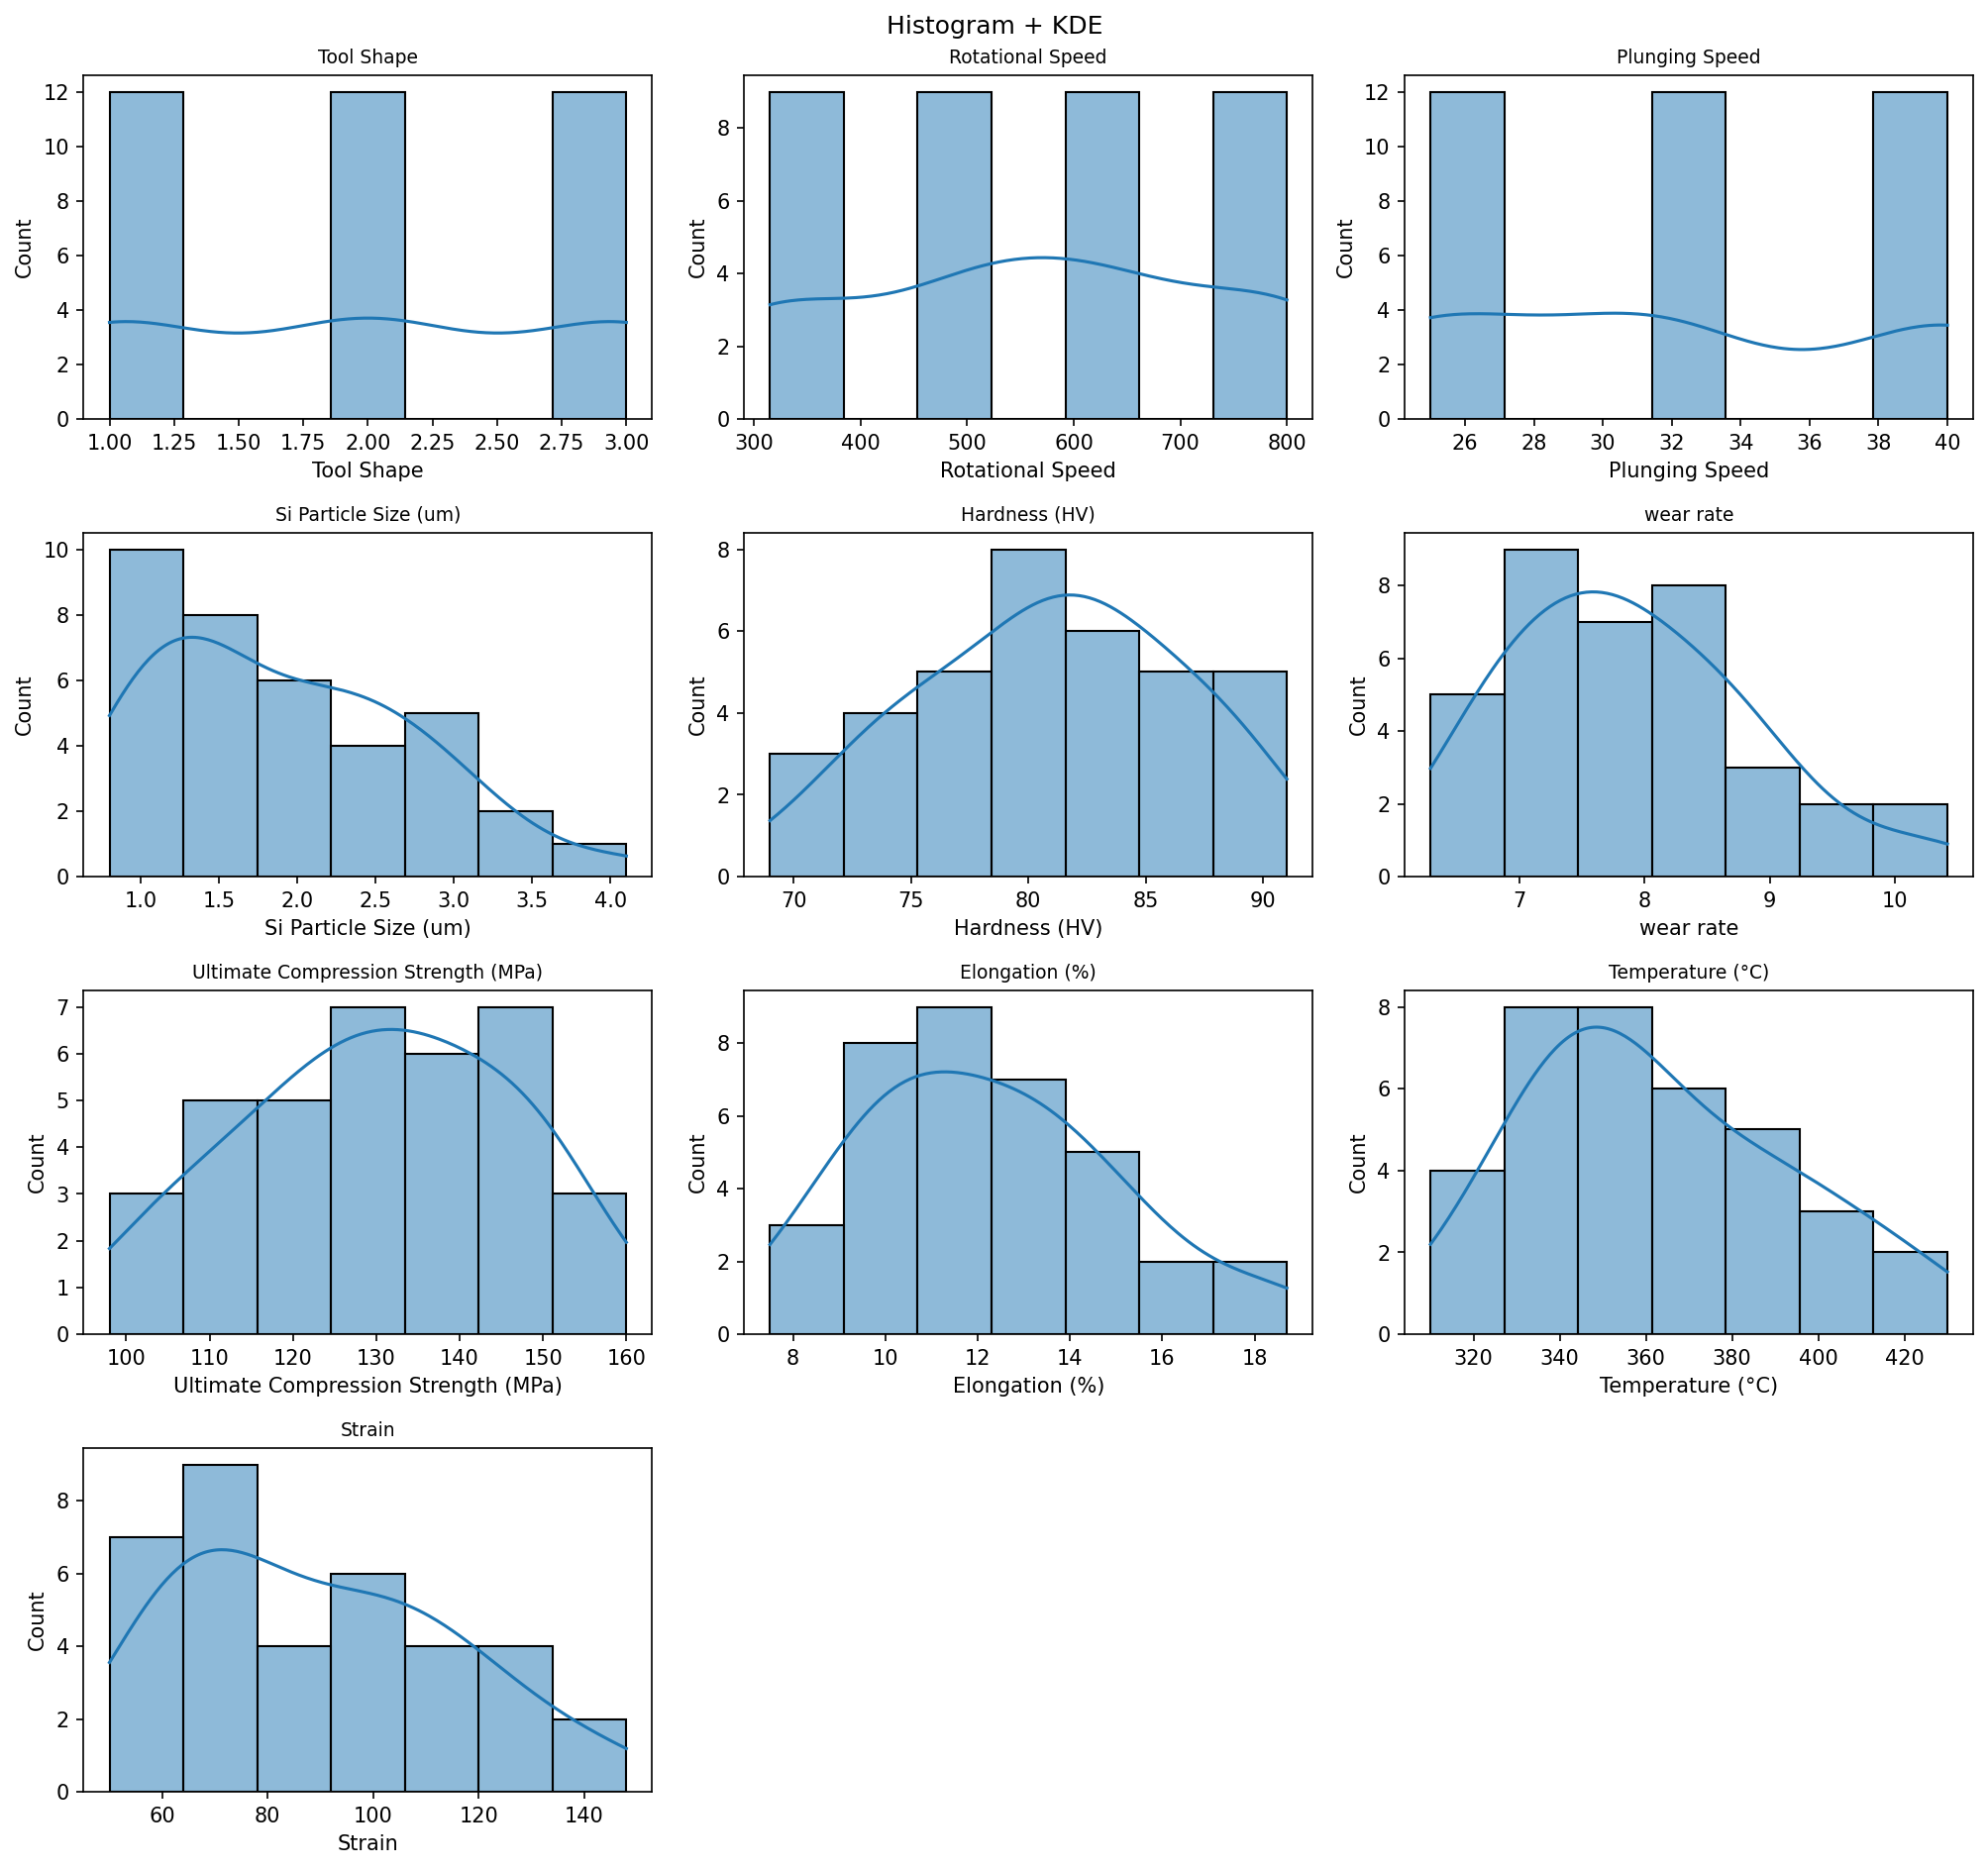

In [4]:
display(Image(filename=str(OUT_DIR / 'histograms_kde.png')))

Boxplot for every numeric variable.

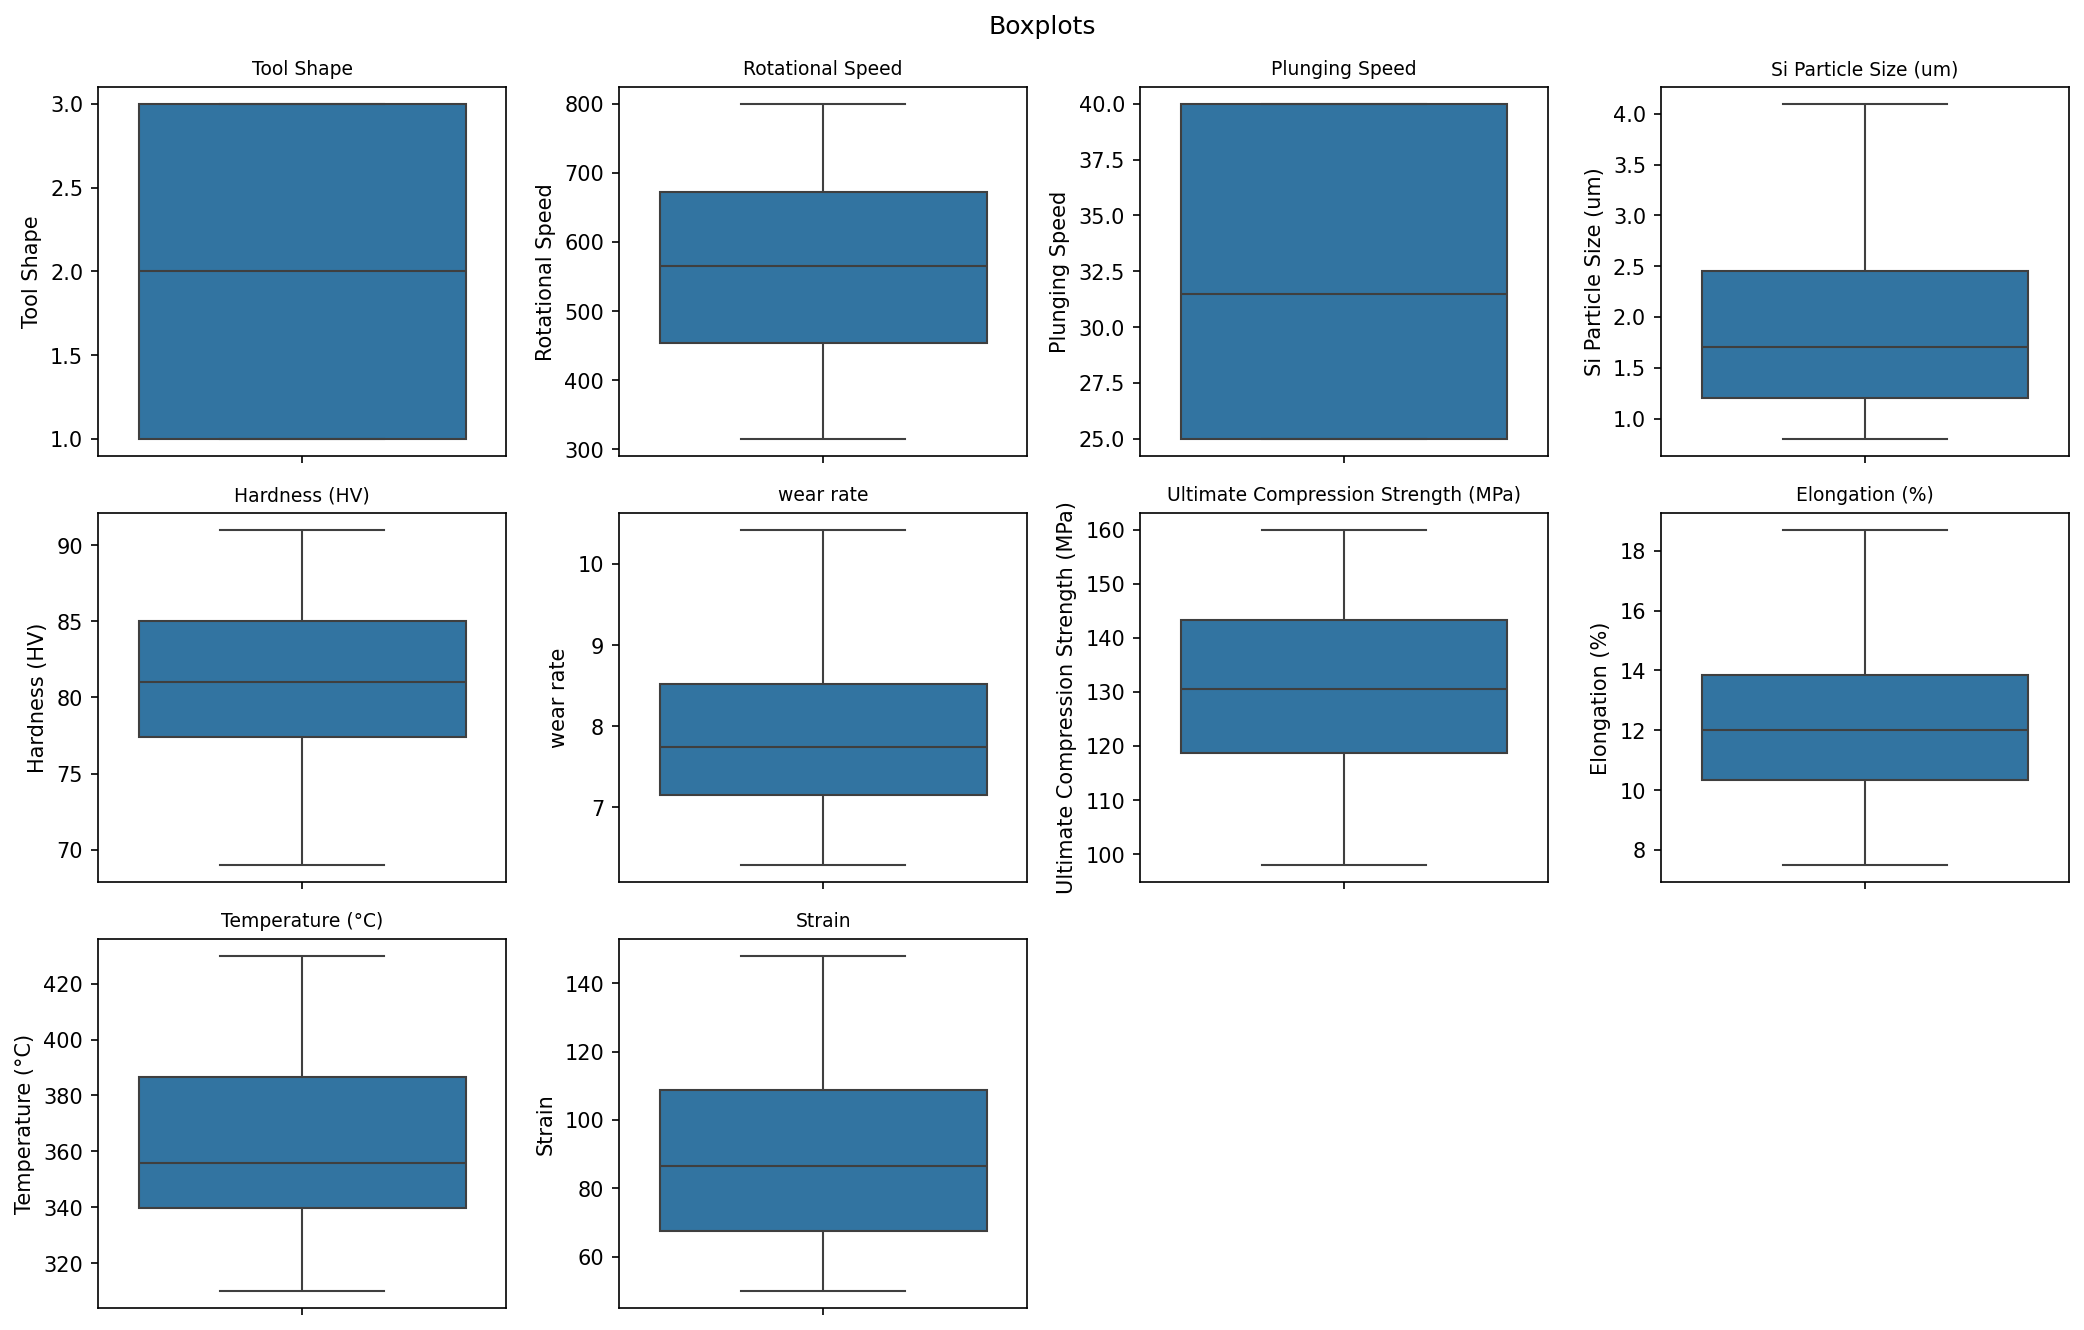

In [5]:
display(Image(filename=str(OUT_DIR / 'boxplots.png')))

QQ-plots against the normal distribution.

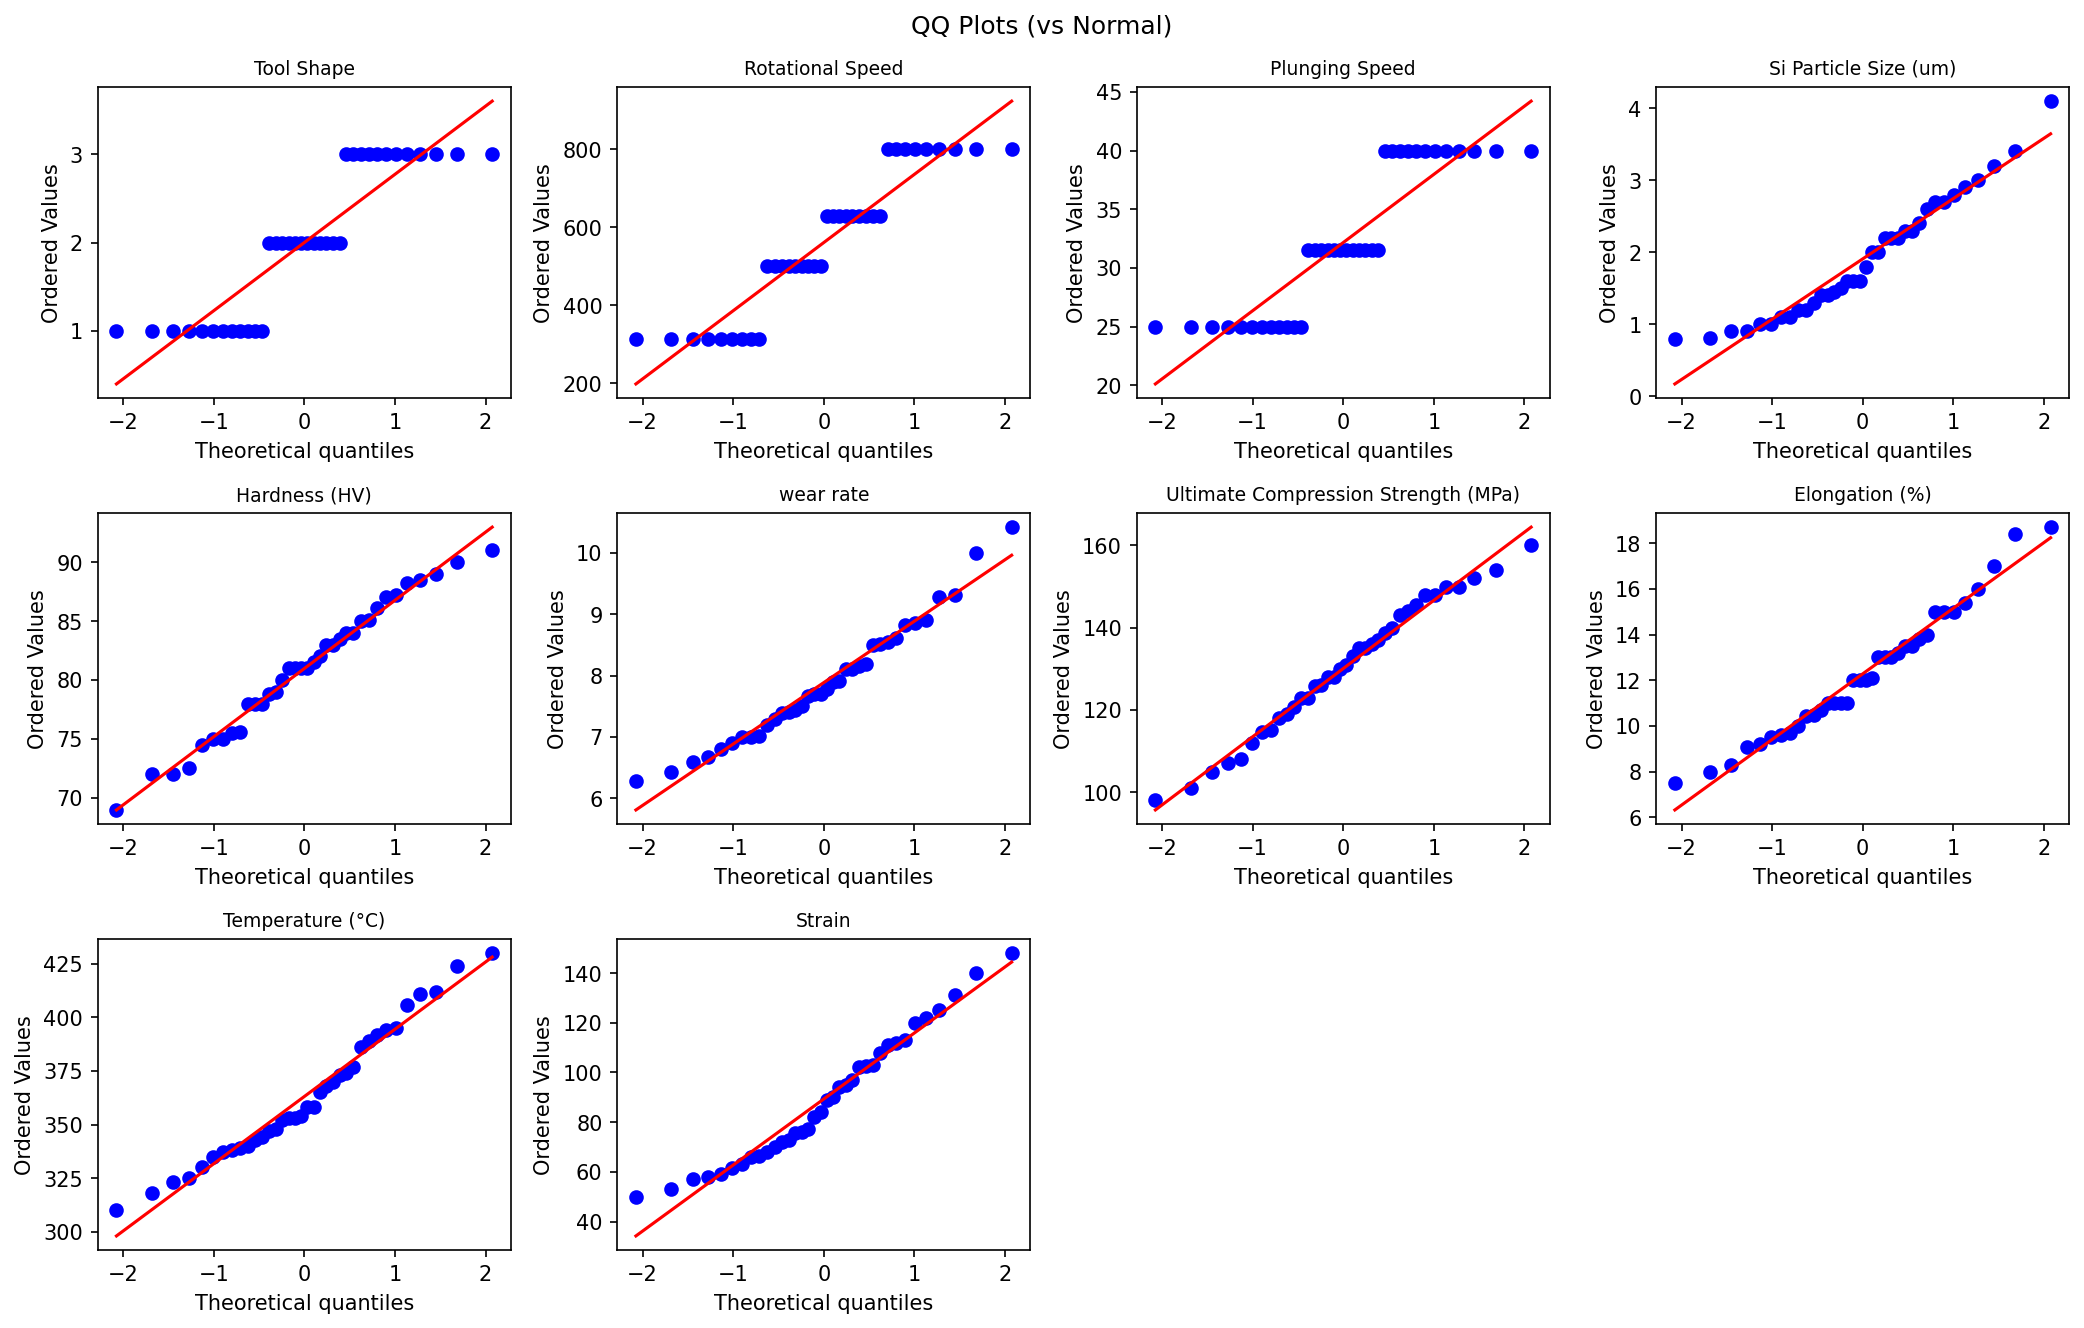

In [6]:
display(Image(filename=str(OUT_DIR / 'qq_plots.png')))

Pair plot of all numeric variables.

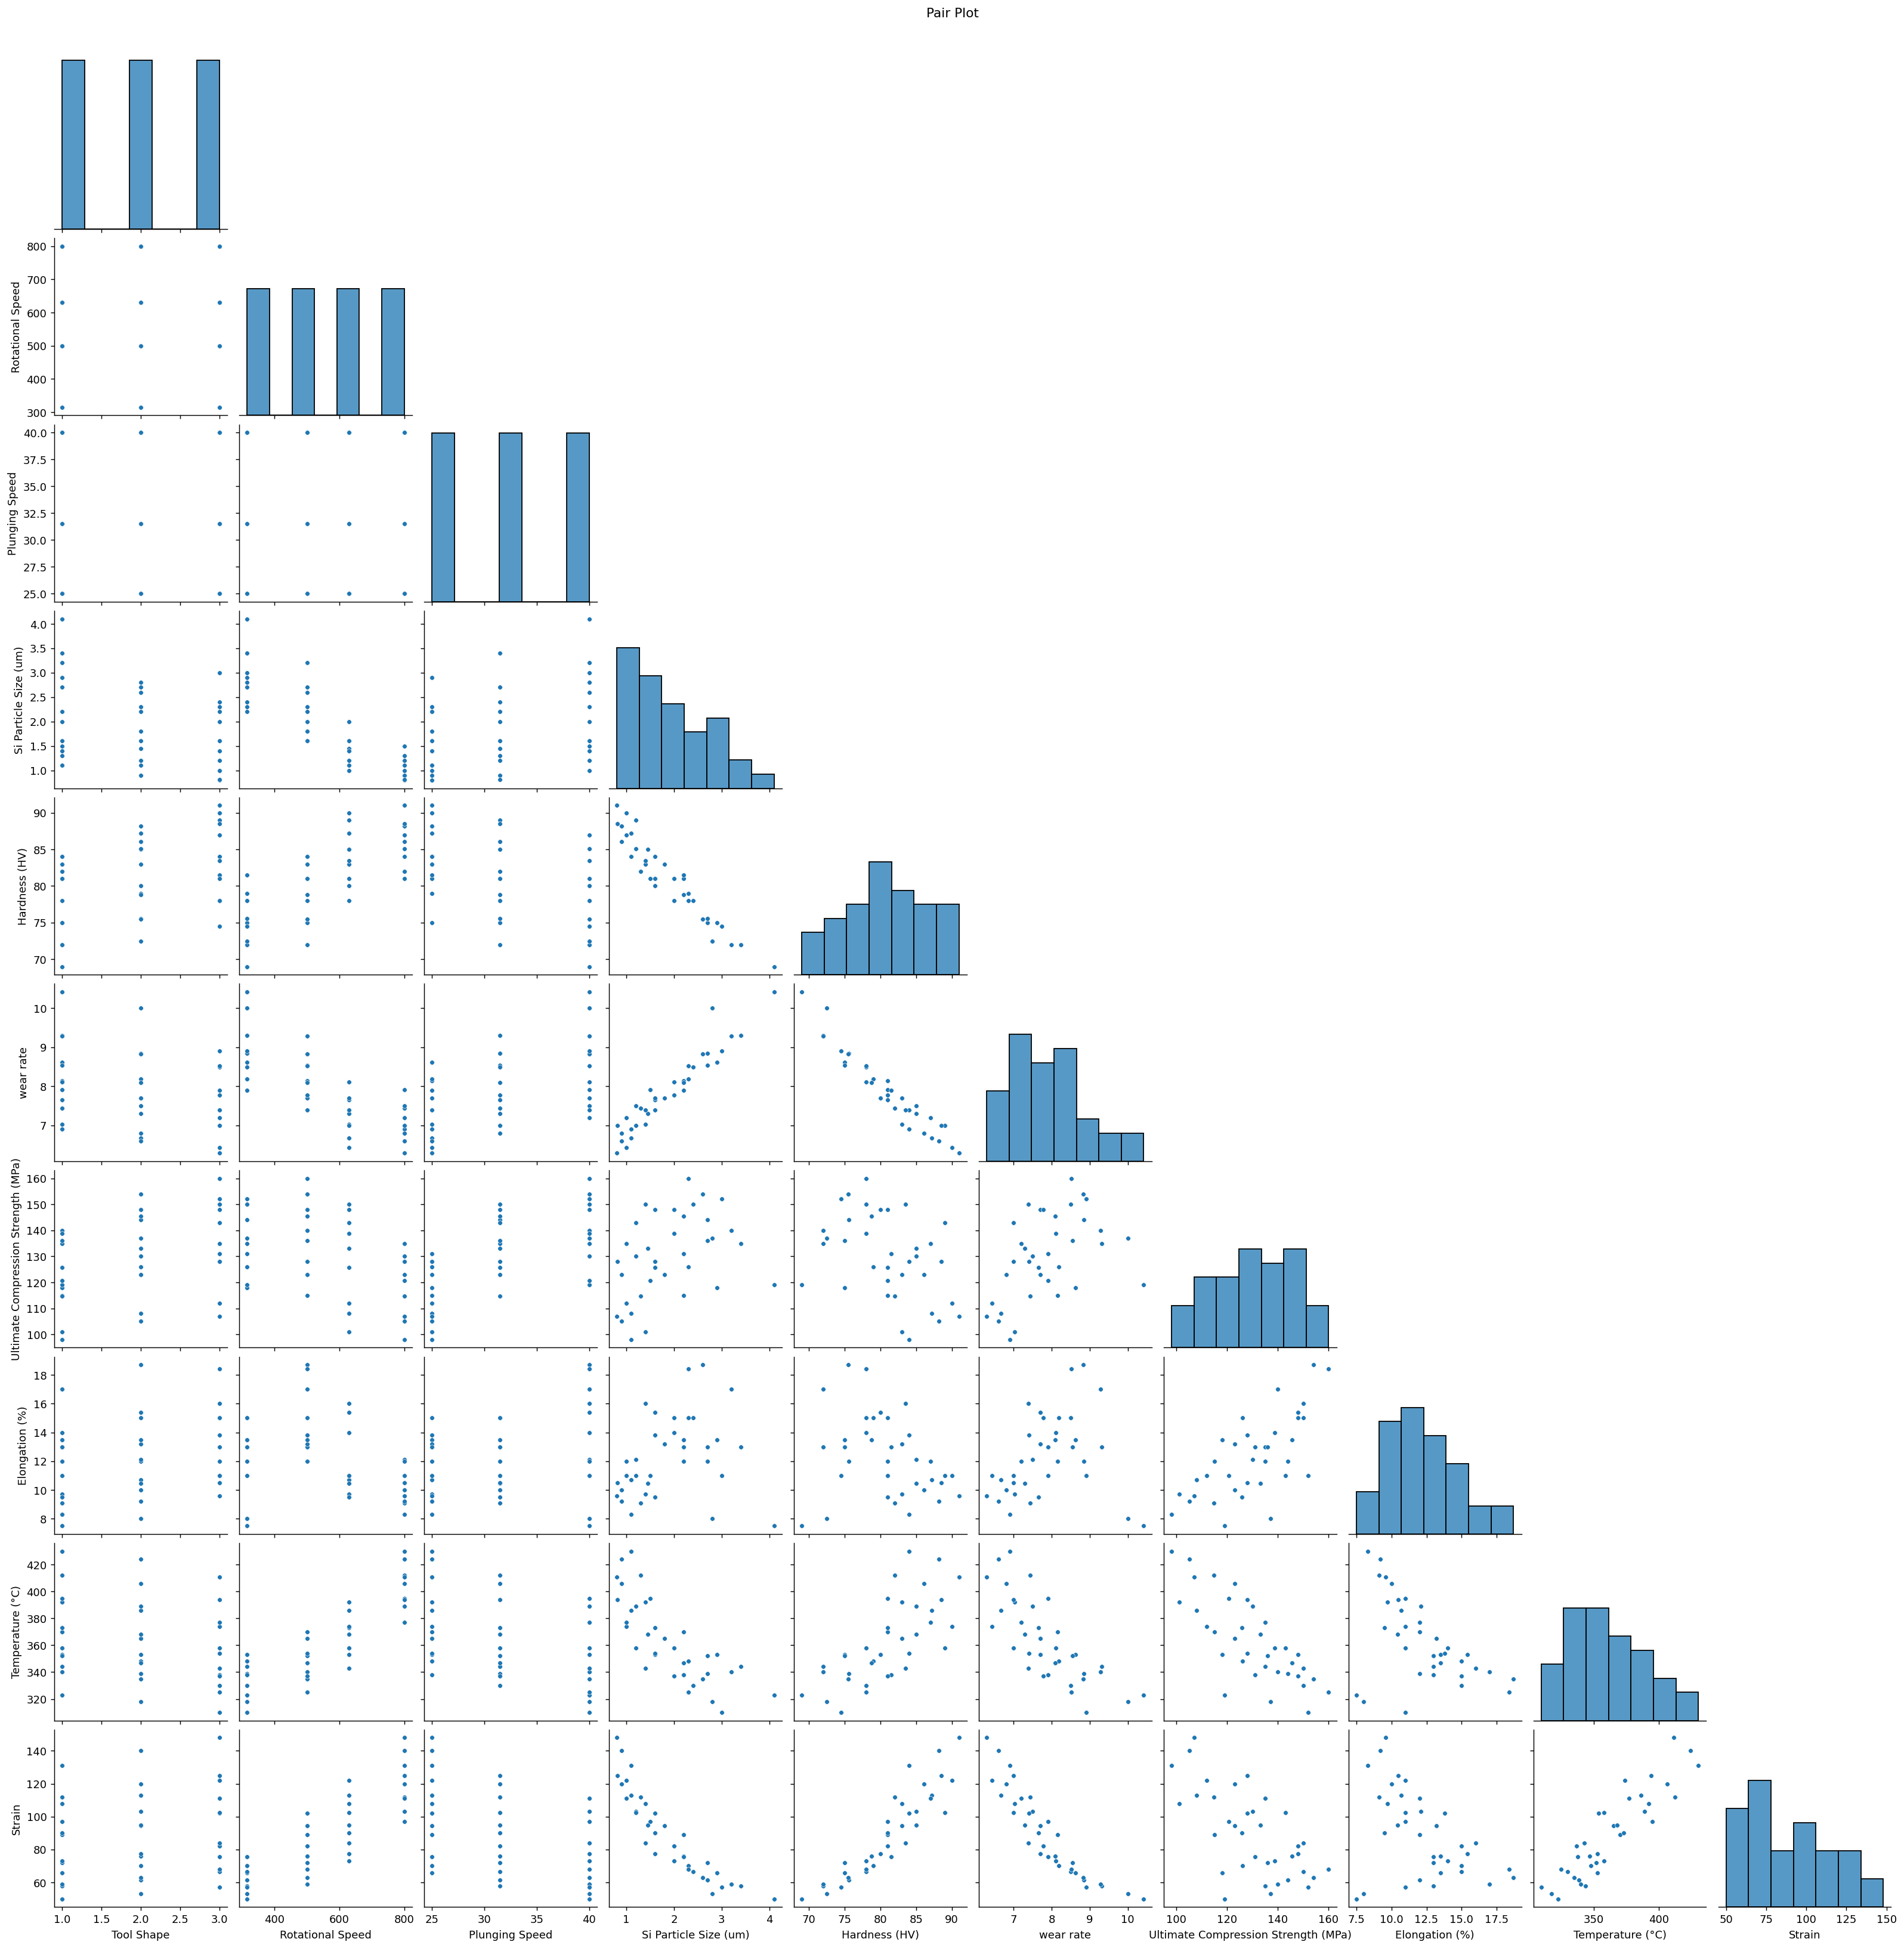

In [7]:
display(Image(filename=str(OUT_DIR / 'pairplot.png')))

Pearson / Spearman / Kendall correlation heatmaps.

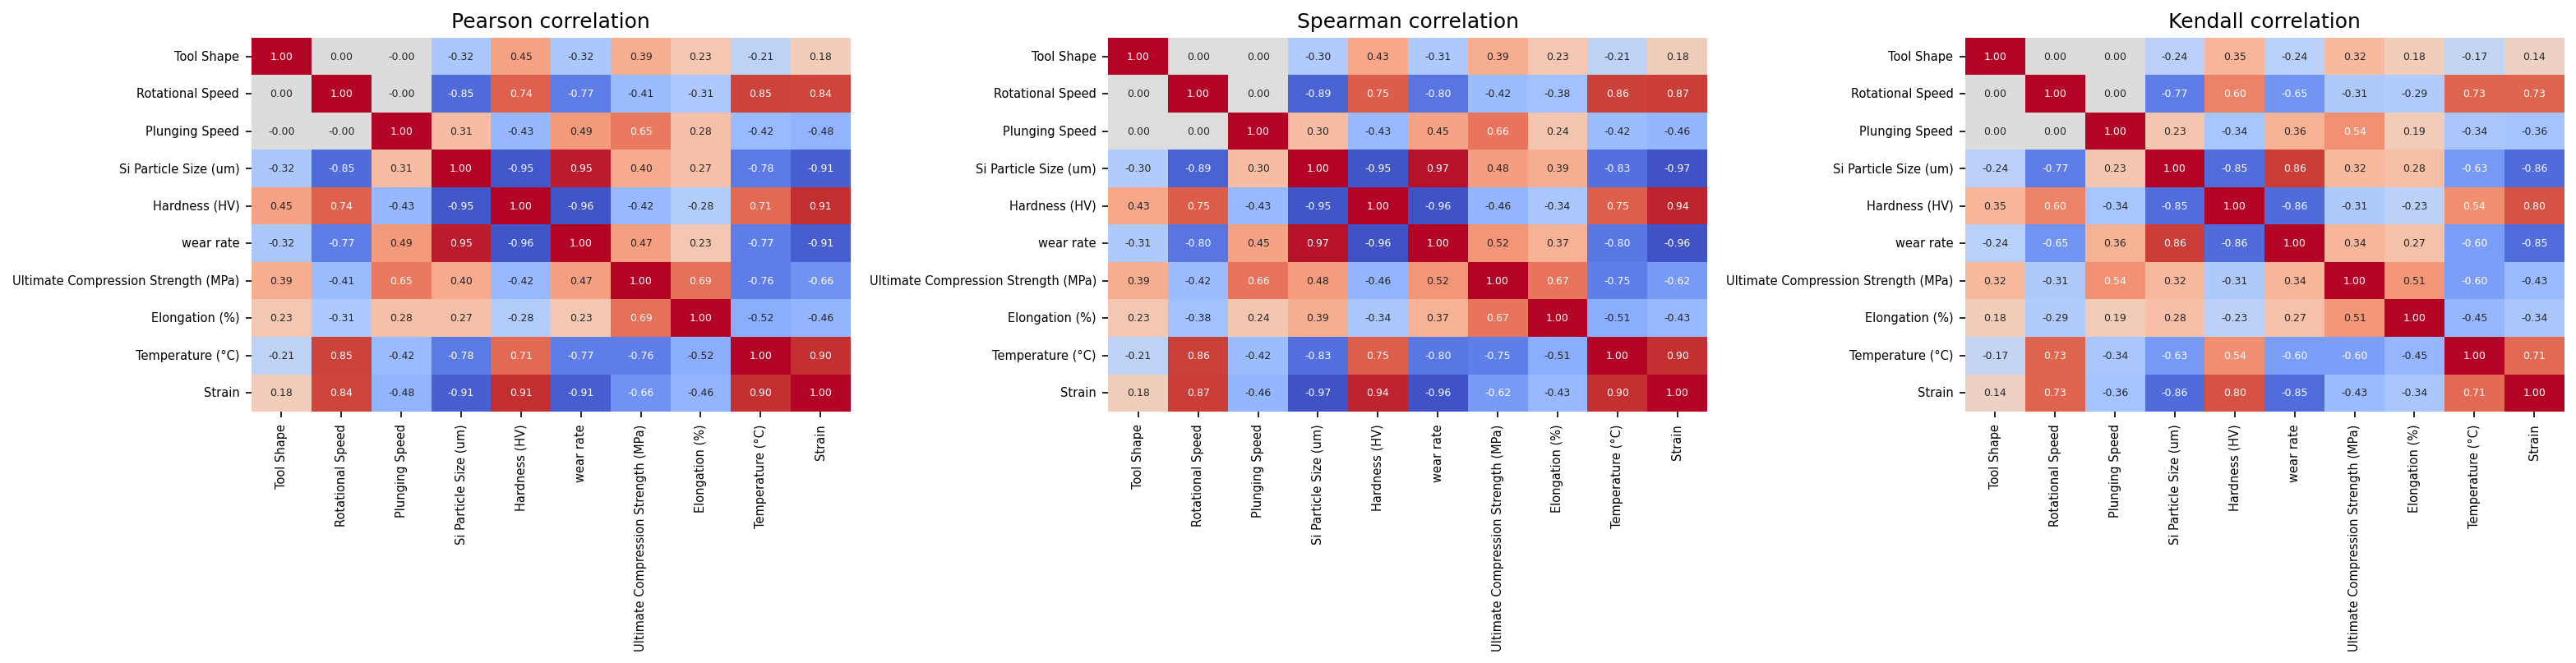

In [8]:
display(Image(filename=str(OUT_DIR / 'correlation_heatmaps.png')))

Descriptive statistics: mean, median, mode, variance, std, skewness, kurtosis.

In [9]:
desc = descriptive_statistics(df)
desc.to_csv(OUT_DIR / 'descriptive_statistics.csv')
desc

,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.00,1.0,0.6857,0.8281,0.0000,-1.5441,1.00,3.00
Rotational Speed,561.2500,565.00,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.00,800.00
Plunging Speed,32.1667,31.50,25.0,38.8000,6.2290,0.1686,-1.5441,25.00,40.00
Si Particle Size (um),1.9072,1.70,1.6,0.6917,0.8317,0.6290,-0.2167,0.80,4.10
Hardness (HV),80.9708,81.00,81.0,31.6618,5.6269,-0.1688,-0.7005,69.00,91.00
wear rate,7.8866,7.74,7.0,0.9650,0.9823,0.6071,0.1189,6.29,10.42
Ultimate Compression Strength (MPa),130.0639,130.50,123.0,260.3681,16.1359,-0.1769,-0.7852,98.00,160.00
Elongation (%),12.2819,12.00,11.0,7.9020,2.8111,0.4736,-0.2403,7.50,18.70
Temperature (°C),363.0833,356.00,353.0,946.8786,30.7714,0.4640,-0.5452,310.00,430.00
Strain,89.3028,86.50,50.0,682.6106,26.1268,0.4502,-0.6964,50.00,148.00


**Interpretation.** The three process inputs (`Tool Shape`, `Rotational Speed`, `Plunging Speed`) have skewness ≈ 0 but strongly negative kurtosis (≈ -1.25 to -1.54): this is the signature of a small, *leveled* DOE (a handful of repeated set points), not a real continuous population — treat their "distribution" as design structure, not as a statistical sample to be normalized.

Among the outputs, `Si Particle Size` (skew 0.63) and `wear rate` (skew 0.61) are the most right-skewed — a few specimens with unusually large particles/wear pull the mean above the median (1.91 vs 1.70 for particle size; 7.89 vs 7.74 for wear rate). `Elongation`, `Temperature` and `Strain` show the same mild right-skew (0.45–0.47). `Hardness` and `Ultimate Compression Strength` are close to symmetric (skew ≈ -0.17 to -0.18). None of the outputs is extreme (|skew| < 1), so a log-transform is not obviously required, but the right-skew in particle size / wear rate is consistent with the strong pairwise correlation between the two noted below.

Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov.

In [10]:
norm = normality_tests(df)
norm.to_csv(OUT_DIR / 'normality_tests.csv', index=False)
norm

,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Si Particle Size (um),0.9444,0.0698,0.5852,0.721,0.1441,0.4051,True
4,Hardness (HV),0.9793,0.7214,0.2110,0.721,0.0854,0.9353,True
5,wear rate,0.9687,0.3900,0.2916,0.721,0.0753,0.9772,True
6,Ultimate Compression Strength (MPa),0.9792,0.7181,0.1949,0.721,0.0664,0.9942,True
7,Elongation (%),0.9704,0.4366,0.3100,0.721,0.1203,0.6316,True
8,Temperature (°C),0.9657,0.3204,0.4342,0.721,0.1212,0.6225,True
9,Strain,0.9581,0.1881,0.4567,0.721,0.1201,0.6333,True


**Interpretation.** Shapiro-Wilk rejects normality (p < 0.05) for `Tool Shape`, `Rotational Speed` and `Plunging Speed` — expected and *not a data-quality concern*: these are discrete DOE set points (e.g. only 3 rotational-speed levels repeated many times), so a normality test on them is measuring the experimental design, not a physical population. All seven **outputs** (`Si Particle Size`, `Hardness`, `wear rate`, `Ultimate Compression Strength`, `Elongation`, `Temperature`, `Strain`) fail to reject normality at 5% (Shapiro p ranges 0.07–0.94; Anderson-Darling and KS agree), so the Gaussian-noise assumption behind linear/Ridge/ElasticNet residuals is reasonable here — though with only 36 samples the tests have low power, so this should be read as "no evidence against normality", not proof of it. This supports using both linear baselines and non-linear models side by side, and cross-checking any linear-model residual diagnostics against the tree/GPR models' predictions.

Correlation tests (Pearson, Spearman, Kendall), sorted by absolute Spearman rho.

In [11]:
corr = correlation_tests(df)
corr.to_csv(OUT_DIR / 'correlation_tests.csv', index=False)
corr.sort_values('spearman_rho', key=abs, ascending=False)

,var_a,var_b,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
29,Si Particle Size (um),Strain,-0.9059,0.0000,-0.9669,0.0000,-0.8572,0.0000
25,Si Particle Size (um),wear rate,0.9528,0.0000,0.9666,0.0000,0.8650,0.0000
30,Hardness (HV),wear rate,-0.9603,0.0000,-0.9640,0.0000,-0.8563,0.0000
38,wear rate,Strain,-0.9136,0.0000,-0.9598,0.0000,-0.8490,0.0000
24,Si Particle Size (um),Hardness (HV),-0.9518,0.0000,-0.9550,0.0000,-0.8451,0.0000
34,Hardness (HV),Strain,0.9114,0.0000,0.9367,0.0000,0.8004,0.0000
44,Temperature (°C),Strain,0.9026,0.0000,0.9020,0.0000,0.7122,0.0000
10,Rotational Speed,Si Particle Size (um),-0.8523,0.0000,-0.8906,0.0000,-0.7676,0.0000
16,Rotational Speed,Strain,0.8409,0.0000,0.8658,0.0000,0.7301,0.0000
15,Rotational Speed,Temperature (°C),0.8502,0.0000,0.8611,0.0000,0.7295,0.0000


**Interpretation.** The input-input correlations are all exactly 0 (p = 1.0): `Tool Shape`, `Rotational Speed` and `Plunging Speed` were varied as an orthogonal DOE, so multicollinearity among the predictors themselves is not a concern for this dataset.

The output-output correlations, in contrast, are very strong and largely non-linear-but-monotonic (Spearman/Kendall consistently exceed Pearson in magnitude): `Si Particle Size` vs `Strain` (r=-0.91, ρ=-0.97), `Si Particle Size` vs `wear rate` (r=0.95, ρ=0.97), `Hardness` vs `wear rate` (r=-0.96, ρ=-0.96), `wear rate` vs `Strain` (r=-0.91, ρ=-0.96), and `Si Particle Size` vs `Hardness` (r=-0.95, ρ=-0.96). Because Spearman/Kendall ≳ Pearson everywhere in this cluster, the true input→output response surface is likely **monotonic but non-linear**, favoring tree ensembles/GPR over the plain linear baseline for these targets — consistent with the project's core design bet.

Among the process inputs, `Rotational Speed` is the dominant driver of the thermal/mechanical response: it correlates strongly with `Temperature` (r=0.85) and `Strain` (r=0.84) — physically plausible, since higher rotational speed increases frictional heat input during the friction process, raising local temperature and inducing more deformation (strain). `Plunging Speed` correlates moderately with `Ultimate Compression Strength` (r=0.65). The `Si Particle Size`↔`Hardness`/`wear rate` links are strong but the causal direction needs mechanical-engineering confirmation (larger embedded Si particles could either reinforce the matrix or act as stress-concentrating/abrasive sites — the sign here, softer + more wear rate at larger particle size, is consistent with the latter).

Bootstrap confidence intervals for Kendall's tau (95%).

In [12]:
kci = kendall_ci_table(df)
kci.to_csv(OUT_DIR / 'kendall_confidence_intervals.csv', index=False)
kci

,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Tool Shape,Si Particle Size (um),-0.2404,0.0717,-0.4756,0.0319
3,Tool Shape,Hardness (HV),0.3467,0.0093,0.1047,0.5620
4,Tool Shape,wear rate,-0.2419,0.0675,-0.4633,-0.0020
5,Tool Shape,Ultimate Compression Strength (MPa),0.3156,0.0173,0.0533,0.5435
6,Tool Shape,Elongation (%),0.1845,0.1675,-0.0814,0.4309
7,Tool Shape,Temperature (°C),-0.1728,0.1916,-0.4305,0.0935
8,Tool Shape,Strain,0.1418,0.2831,-0.1239,0.3887
9,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923


Outlier detection with IQR, LOF and Isolation Forest — samples are flagged, never removed.

In [13]:
outl = outlier_report(df)
outl.to_csv(OUT_DIR / 'outlier_report.csv')
flagged = outl[outl['n_methods_flagging'] > 0]
print(f'{len(flagged)} of {len(outl)} samples flagged by at least one method')
flagged

4 of 36 samples flagged by at least one method


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
2,False,False,True,1
5,False,False,True,1
26,False,False,True,1
33,False,False,True,1


**Interpretation.** Only 4/36 samples (11%) are flagged, all by Isolation Forest alone (row indices 2, 5, 26, 33) — none of them is corroborated by IQR or LOF, and none is flagged by 2+ methods simultaneously. This is a *weak, low-confidence* outlier signal rather than a clear anomaly: Isolation Forest's `contamination=0.1` default guarantees it will always mark ~10% of any dataset, so a single-method flag here is expected noise more than a red flag. Consistent with the assignment's instruction, **none of these rows is removed** — in a small, mechanically-generated DOE dataset like this, an unusual combination of `Rotational Speed`/`Plunging Speed` at the corners of the design space is a legitimate physical operating point, not a measurement error, and should only ever be excluded with an explicit mechanical justification (none was found here).

## Summary — Dataset_0136

All result tables for this dataset, displayed in full (already saved as individual CSVs under `results/eda/Dataset_0136/`).

In [14]:
print('=' * 90)
print('1) DESCRIPTIVE STATISTICS')
print('=' * 90)
display(desc)

print('=' * 90)
print('2) NORMALITY TESTS')
print('=' * 90)
display(norm)

print('=' * 90)
print('3) CORRELATION TESTS (Pearson / Spearman / Kendall)')
print('=' * 90)
display(corr)

print('=' * 90)
print('4) KENDALL TAU BOOTSTRAP CONFIDENCE INTERVALS')
print('=' * 90)
display(kci)

print('=' * 90)
print('5) OUTLIER REPORT (flagged only, nothing removed)')
print('=' * 90)
display(outl)
n_flagged = int((outl['n_methods_flagging'] > 0).sum())
print(f'\n{n_flagged}/{len(outl)} samples flagged by at least one method '
      f'(IQR / LOF / Isolation Forest). No row is removed.')

print('\nAll EDA results (figures + CSV tables) saved to:', OUT_DIR.resolve())

1) DESCRIPTIVE STATISTICS


,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.00,1.0,0.6857,0.8281,0.0000,-1.5441,1.00,3.00
Rotational Speed,561.2500,565.00,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.00,800.00
Plunging Speed,32.1667,31.50,25.0,38.8000,6.2290,0.1686,-1.5441,25.00,40.00
Si Particle Size (um),1.9072,1.70,1.6,0.6917,0.8317,0.6290,-0.2167,0.80,4.10
Hardness (HV),80.9708,81.00,81.0,31.6618,5.6269,-0.1688,-0.7005,69.00,91.00
wear rate,7.8866,7.74,7.0,0.9650,0.9823,0.6071,0.1189,6.29,10.42
Ultimate Compression Strength (MPa),130.0639,130.50,123.0,260.3681,16.1359,-0.1769,-0.7852,98.00,160.00
Elongation (%),12.2819,12.00,11.0,7.9020,2.8111,0.4736,-0.2403,7.50,18.70
Temperature (°C),363.0833,356.00,353.0,946.8786,30.7714,0.4640,-0.5452,310.00,430.00
Strain,89.3028,86.50,50.0,682.6106,26.1268,0.4502,-0.6964,50.00,148.00


2) NORMALITY TESTS


,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Si Particle Size (um),0.9444,0.0698,0.5852,0.721,0.1441,0.4051,True
4,Hardness (HV),0.9793,0.7214,0.2110,0.721,0.0854,0.9353,True
5,wear rate,0.9687,0.3900,0.2916,0.721,0.0753,0.9772,True
6,Ultimate Compression Strength (MPa),0.9792,0.7181,0.1949,0.721,0.0664,0.9942,True
7,Elongation (%),0.9704,0.4366,0.3100,0.721,0.1203,0.6316,True
8,Temperature (°C),0.9657,0.3204,0.4342,0.721,0.1212,0.6225,True
9,Strain,0.9581,0.1881,0.4567,0.721,0.1201,0.6333,True


3) CORRELATION TESTS (Pearson / Spearman / Kendall)


...

4) KENDALL TAU BOOTSTRAP CONFIDENCE INTERVALS


,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Tool Shape,Si Particle Size (um),-0.2404,0.0717,-0.4756,0.0319
3,Tool Shape,Hardness (HV),0.3467,0.0093,0.1047,0.5620
4,Tool Shape,wear rate,-0.2419,0.0675,-0.4633,-0.0020
5,Tool Shape,Ultimate Compression Strength (MPa),0.3156,0.0173,0.0533,0.5435
6,Tool Shape,Elongation (%),0.1845,0.1675,-0.0814,0.4309
7,Tool Shape,Temperature (°C),-0.1728,0.1916,-0.4305,0.0935
8,Tool Shape,Strain,0.1418,0.2831,-0.1239,0.3887
9,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923


5) OUTLIER REPORT (flagged only, nothing removed)


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
0,False,False,False,0
1,False,False,False,0
2,False,False,True,1
3,False,False,False,0
4,False,False,False,0
5,False,False,True,1
6,False,False,False,0
7,False,False,False,0
8,False,False,False,0
9,False,False,False,0



4/36 samples flagged by at least one method (IQR / LOF / Isolation Forest). No row is removed.

All EDA results (figures + CSV tables) saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_0136


## Key takeaways — Dataset_0136 (n=36)

1. **Design structure, not noise:** the three inputs are orthogonal DOE levels (all pairwise correlations = 0, all fail normality by construction) — no multicollinearity among predictors.
2. **Non-linear, monotonic response surface:** the output cluster `{Si Particle Size, Hardness, wear rate, Strain}` is inter-correlated at |r| ≳ 0.9 with Spearman/Kendall consistently above Pearson, i.e. real but non-linear relationships — this is direct evidence that tree ensembles / GPR should out-perform the Linear Regression baseline on these targets, which is exactly what the multi-criteria Top-3 selection should be checked against downstream.
3. **Physically plausible driver:** `Rotational Speed` → `Temperature` → `Strain` is the clearest mechanistically-explainable chain (frictional heat generation scales with rotational speed).
4. **Outputs are approximately normal, inputs are not** — expected, and supports comparing linear and non-linear model families rather than ruling either out a priori.
5. **Outliers are flagged but weak and uncorroborated (4/36, single-method only)** — kept in the modelling data per the assignment's "no removal without mechanical justification" rule; this dataset also has the *only* two Level-A-exclusive outputs of the whole project (`Temperature`, `Strain`), and both are unusually strongly tied to `Rotational Speed`, so any surrogate for these two targets should be judged partly on whether it recovers that physical link (see the SHAP dependence plots in Phase 6).